In [1]:
import pandas as pd
import numpy as np

import MDAnalysis
import tqdm

import matplotlib.pyplot as plt
from MDAnalysis.analysis import leaflet

import seaborn as sns


/Users/jesucastin/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/jesucastin/anaconda3/lib/python3.11/site-packages/MDAnalysis/topology/TPRParser.py:161: DeprecationWarning: 'xdrlib' is deprecated and slated for removal in Python 3.13
  import xdrlib


In [2]:
prefix_path='../../../LC3_MAIN_TRAJECTORIES/PROTEIN_MEMBRANE'

#UNB
LC3B_UNB_ER=MDAnalysis.Universe('%s/membrane_bound_apo/LC3B-ER-md-1us-compact-center_0ns.gro'%prefix_path,
                               '%s/membrane_bound_apo/LC3B-ER-md-1us-compact-center-dt1000-noW.xtc'%prefix_path,
                               '%s/membrane_bound_apo/LC3B-ER-md-1us-compact-center-dt1000-noW_SIM2.xtc'%prefix_path,
                               '%s/membrane_bound_apo/LC3B-ER-md-1us-compact-center-dt1000-noW_SIM3.xtc'%prefix_path)


In [3]:
up_lf_unb=leaflet.LeafletFinder(LC3B_UNB_ER, 'name P')
up_lf_unb_a_id=[i.id for i in up_lf_unb.group(0).atoms if i.resid !=120] # NOT considering GLP 120

In [4]:
def lipid_res_dist_all(traj, res, atomgroup):
    min_dist_dis_charged_gr_P=[]
    for ts in tqdm.tqdm(traj.trajectory):
        charged_group=traj.select_atoms('resid %d and name %s'%(res,atomgroup))
        charged_group_charged=charged_group.positions

        dis_charged_gr_P_ls=[]
        
        for lipid_ind in up_lf_unb_a_id:
            lipid_sel=traj.select_atoms('id %d'%lipid_ind)
#             if lipid_sel.resnames[0]==lipid_type:
            P_lipid_charged=lipid_sel.positions

            dis_charged_gr_P=np.linalg.norm(P_lipid_charged - charged_group_charged)
            dis_charged_gr_P_ls.append(dis_charged_gr_P)
        
        min_dist_dis_charged_gr_P.append(min(dis_charged_gr_P_ls))
    return min_dist_dis_charged_gr_P

In [5]:
pos_res_mtm_R=[10,37] #all ARG
pos_res_mtm_K=[5,8,39,42] # all LYS
neg_res_mtm_E=[4,36,41,117] # all GLU


In [6]:
res_lipid_dist_df=pd.DataFrame()

for i in pos_res_mtm_R:
    res_lipid_dist_df[i]=lipid_res_dist_all(LC3B_UNB_ER,i,'NH2') # POSITIVE CHARGED GROUP FOR ARG

for i in pos_res_mtm_K:
    res_lipid_dist_df[i]=lipid_res_dist_all(LC3B_UNB_ER,i,'NZ') # POSITIVE CHARGED GROUP FOR LYS
for i in neg_res_mtm_E:
    res_lipid_dist_df[i]=lipid_res_dist_all(LC3B_UNB_ER,i,'OE1') # POSITIVE CHARGED GROUP FOR GLU

# for i in neg_res_mtm_D:
#     res_lipid_dist_df[i]=lipid_res_dist_all(LC3B_UNB_ER,i,'OD1') # POSITIVE CHARGED GROUP FOR ASP

100%|████████████████████████████| 3003/3003 [00:50<00:00, 58.92it/s]


In [7]:
condensed_df=pd.DataFrame()
# condensed_df['Residue']=res_lipid_dist_df
residue_ls=[]
dist_ls=[]
order_=['A','B','C','D','E','F','G','H','I','J'] # ARRANGING through assigning alphabets
res_order=[5,42,37,10,39,8,4,41,36,117]

for ORD, res in enumerate(res_order):
    order_it=order_[ORD]
    for dist in res_lipid_dist_df[res]:
        residue_ls.append('%s %d'%(order_it,res))
        dist_ls.append(dist)
        
condensed_df['Residue']=residue_ls
condensed_df['Distance']=dist_ls
condensed_df

,Residue,Distance
0,A 5,16.130264
1,A 5,12.140288
2,A 5,7.797320
3,A 5,9.082789
4,A 5,8.492772
...,...,...
30025,J 117,12.185618
30026,J 117,6.337956
30027,J 117,7.831756
30028,J 117,6.601244


/Users/jesucastin/anaconda3/lib/python3.11/site-packages/joypy/joyplot.py:435: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  fig, axes = _subplots(naxes=num_axes, ax=ax, squeeze=False,


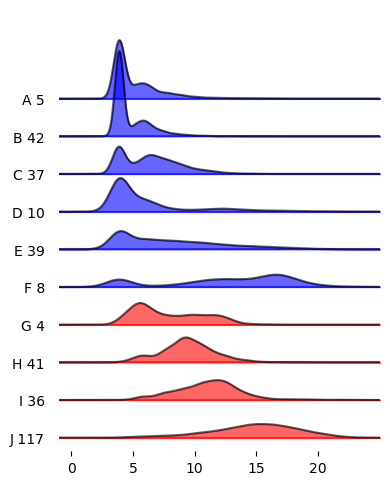

In [10]:
from joypy import joyplot

font = {'family':'helvetica neue',
    'color':  'black',
    'weight': 'bold',
    'size': 11
    }
rs={'family':'helvetica neue',
    'size':10
   }

fig, ax = plt.subplots(figsize=(4, 5))

joyplot(
    data=condensed_df[['Distance', 'Residue']],
    by="Residue",
    column='Distance',
    ylabelsize=10,
    legend=False,
    alpha=0.6,
    ax=ax,
    color=['blue','blue','blue','blue','blue','blue',
 'red','red','red','red'],  # Pass the colors list; blue- positive; red- negative
    x_range=[-1,25],
    normalize=True,
    linecolor=None

    
)

# ax.set_xlim(-15,27)
plt.savefig('../../plots/geometric_analysis/UNB_Charged_group_and_Lipid_head_distance_ridgeline.png', dpi=650,
           bbox_inches='tight',transparent=True)
plt.show()

In [13]:
res_lipid_dist_df["SIM-Frame"]=["S1-%d"%i for i in range(1,1002)]+["S2-%d"%i for i in range(1,1002)]+["S3-%d"%i for i in range(1,1002)]
res_lipid_dist_df

,10,37,5,8,39,42,4,36,41,117,SIM-Frame
0,23.617874,14.609773,16.130264,23.475985,12.459626,8.927489,15.745556,21.864389,13.438707,14.578629,S1-1
1,19.561005,10.858896,12.140288,23.011576,10.994256,5.932812,16.187952,17.423748,6.995957,10.649370,S1-2
2,18.892784,7.677969,7.797320,18.889585,9.628637,4.017687,14.598654,15.776972,6.380457,10.670131,S1-3
3,18.826403,7.636707,9.082789,19.512634,8.896577,3.757417,13.597172,17.894682,7.963456,10.395205,S1-4
4,16.732355,6.887136,8.492772,19.717272,6.903000,5.795054,13.247336,17.800964,6.187626,9.639507,S1-5
...,...,...,...,...,...,...,...,...,...,...,...
2998,4.354330,3.885667,3.556305,17.703613,12.556008,4.540529,5.278202,9.738548,9.110353,12.185618,S3-997
2999,4.106297,4.079257,3.814826,15.975385,13.062047,6.357500,5.679409,11.001297,8.177988,6.337956,S3-998
3000,6.199017,3.774668,3.860203,17.741226,11.581621,6.607654,5.839471,12.997808,9.299952,7.831756,S3-999
3001,6.375870,3.836381,4.010660,16.560566,10.333149,3.746184,5.815392,10.736948,7.553686,6.601244,S3-1000


In [14]:
# res_lipid_dist_df.to_csv("../../../LC3_paper_data_files_for_source_data_comp/CHARGED_RESID_LIPID_HEAD_UNB_dat.csv")

In [ ]:
# restart the kernel here

In [1]:
# FOR BND (run from here)

import pandas as pd
import numpy as np

import MDAnalysis
import tqdm

import matplotlib.pyplot as plt
from MDAnalysis.analysis import leaflet

import seaborn as sns



prefix_path='../../../LC3_MAIN_TRAJECTORIES/PROTEIN_MEMBRANE'


#BND
LC3B_BND_ER=MDAnalysis.Universe('%s/membrane_bound_apo_LIR/LC3B-p62-SIM1-ER-0ns.gro'%prefix_path,
                               '%s/membrane_bound_apo_LIR/LC3B-p62-ER-md-1us-cluster-compact-center-dt1000-noW.xtc'%prefix_path,
                               '%s/membrane_bound_apo_LIR/LC3B-p62-ER-SIM2-cluster-compact-center-dt1000-now.xtc'%prefix_path,
                               '%s/membrane_bound_apo_LIR/LC3B-p62-ER-md-SIM3-1us-cluster-compact-center-noW-dt1000.xtc'%prefix_path)





/Users/jesucastin/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/jesucastin/anaconda3/lib/python3.11/site-packages/MDAnalysis/topology/TPRParser.py:161: DeprecationWarning: 'xdrlib' is deprecated and slated for removal in Python 3.13
  import xdrlib


In [2]:
up_lf_bnd=leaflet.LeafletFinder(LC3B_BND_ER, 'name P') #selecting upplerleaflet
up_lf_bnd_a_id=[i.id for i in up_lf_bnd.group(0).atoms if i.resid !=120] # NOT considering GLP 120

In [3]:
def lipid_res_dist_all(traj, res, atomgroup):
    min_dist_dis_charged_gr_P=[]
    for ts in tqdm.tqdm(traj.trajectory):
        charged_group=traj.select_atoms('resid %d and name %s'%(res,atomgroup))
        charged_group_charged=charged_group.positions

        dis_charged_gr_P_ls=[]
        
        for lipid_ind in up_lf_bnd_a_id:
            lipid_sel=traj.select_atoms('id %d'%lipid_ind)
#             if lipid_sel.resnames[0]==lipid_type:
            P_lipid_charged=lipid_sel.positions

            dis_charged_gr_P=np.linalg.norm(P_lipid_charged - charged_group_charged)
            dis_charged_gr_P_ls.append(dis_charged_gr_P)
        
        min_dist_dis_charged_gr_P.append(min(dis_charged_gr_P_ls))
    return min_dist_dis_charged_gr_P

In [4]:
pos_res_mtm_R=[10,37] #all ARG
pos_res_mtm_K=[5,8,39,42] # all LYS
neg_res_mtm_E=[4,36,41,117] # all GLU

In [5]:
res_lipid_dist_df=pd.DataFrame()

for i in pos_res_mtm_R:
    res_lipid_dist_df[i]=lipid_res_dist_all(LC3B_BND_ER,i,'NH2') # POSITIVE CHARGED GROUP FOR ARG

for i in pos_res_mtm_K:
    res_lipid_dist_df[i]=lipid_res_dist_all(LC3B_BND_ER,i,'NZ') # POSITIVE CHARGED GROUP FOR LYS
for i in neg_res_mtm_E:
    res_lipid_dist_df[i]=lipid_res_dist_all(LC3B_BND_ER,i,'OE1') # POSITIVE CHARGED GROUP FOR GLU

# for i in neg_res_mtm_D:
#     res_lipid_dist_df[i]=lipid_res_dist_all(LC3B_UNB_ER,i,'OD1') # POSITIVE CHARGED GROUP FOR ASP

100%|█████████████████████████████████████████████████████████████████████████████████████████| 3003/3003 [00:52<00:00, 56.88it/s]


In [6]:
condensed_df=pd.DataFrame()
# condensed_df['Residue']=res_lipid_dist_df
residue_ls=[]
dist_ls=[]
order_=['A','B','C','D','E','F','G','H','I','J'] # ARRANGING through assigning alphabets
res_order=[5,42,37,10,39,8,4,41,36,117]

for ORD, res in enumerate(res_order):
    order_it=order_[ORD]
    for dist in res_lipid_dist_df[res]:
        residue_ls.append('%s %d'%(order_it,res))
        dist_ls.append(dist)
        
condensed_df['Residue']=residue_ls
condensed_df['Distance']=dist_ls
condensed_df

,Residue,Distance
0,A 5,19.231737
1,A 5,8.396406
2,A 5,13.396770
3,A 5,9.931492
4,A 5,9.396489
...,...,...
30025,J 117,15.305866
30026,J 117,14.572528
30027,J 117,16.961849
30028,J 117,15.577924


/Users/jesucastin/anaconda3/lib/python3.11/site-packages/joypy/joyplot.py:435: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  fig, axes = _subplots(naxes=num_axes, ax=ax, squeeze=False,


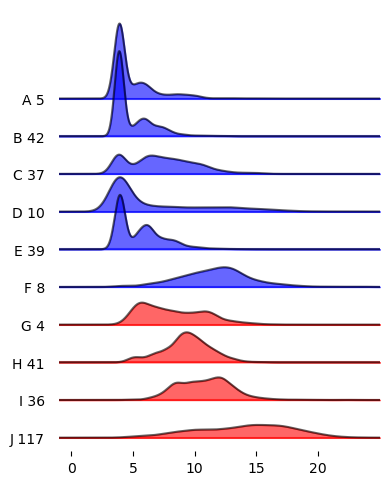

In [7]:
from joypy import joyplot

font = {'family':'helvetica neue',
    'color':  'black',
    'weight': 'bold',
    'size': 11
    }
rs={'family':'helvetica neue',
    'size':10
   }

fig, ax = plt.subplots(figsize=(4, 5))

joyplot(
    data=condensed_df[['Distance', 'Residue']],
    by="Residue",
    column='Distance',
    ylabelsize=10,
    legend=False,
    alpha=0.6,
    ax=ax,
    color=['blue','blue','blue','blue','blue','blue',
 'red','red','red','red'],  # Pass the colors list; blue- positive; red- negative
    x_range=[-1,25],
    normalize=True,
    linecolor=None

    
)

# ax.set_xlim(-15,27)
plt.savefig('../../plots/geometric_analysis/BND_Charged_group_and_Lipid_head_distance_ridgeline.png', dpi=650,
           bbox_inches='tight',transparent=True)
plt.show()